(<Axes: >, <matplotlib.image.AxesImage at 0x307e2f890>)

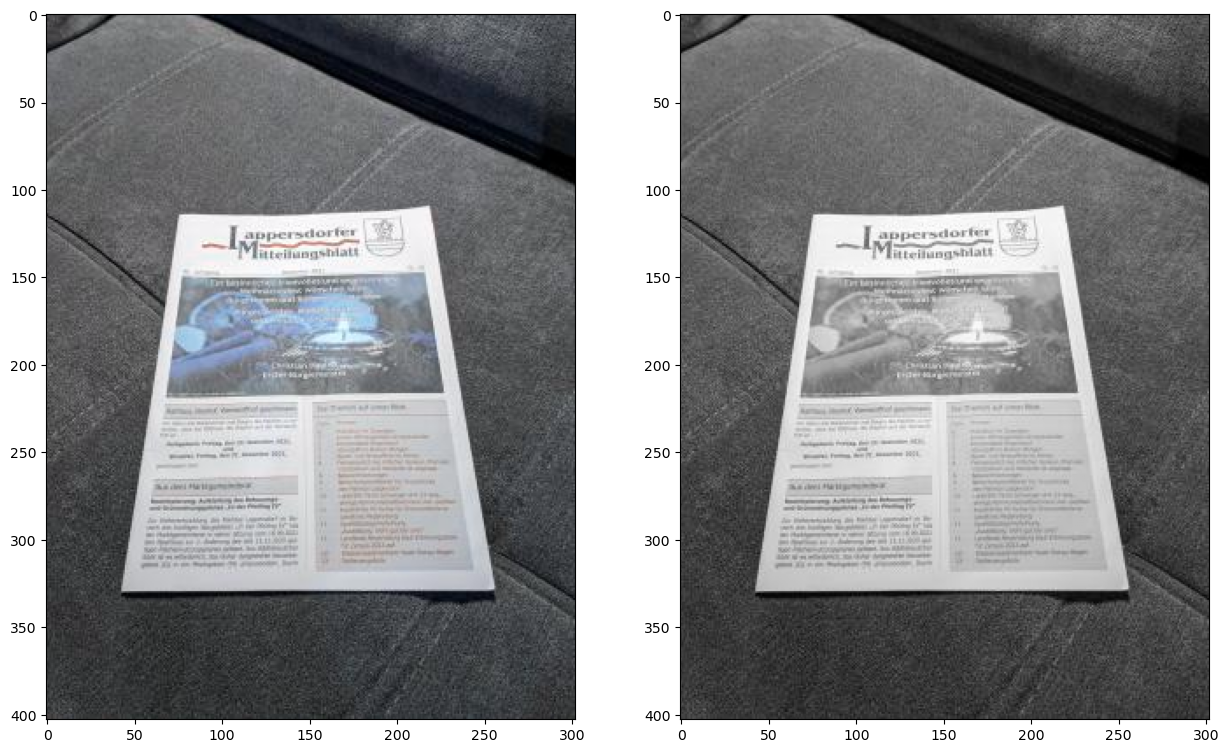

In [36]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

img = cv2.imread('document.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255
rows, cols = gray.shape

# Let's plot the image
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(gray, cmap='gray')

(<Axes: >, <matplotlib.image.AxesImage at 0x307f3ae90>)

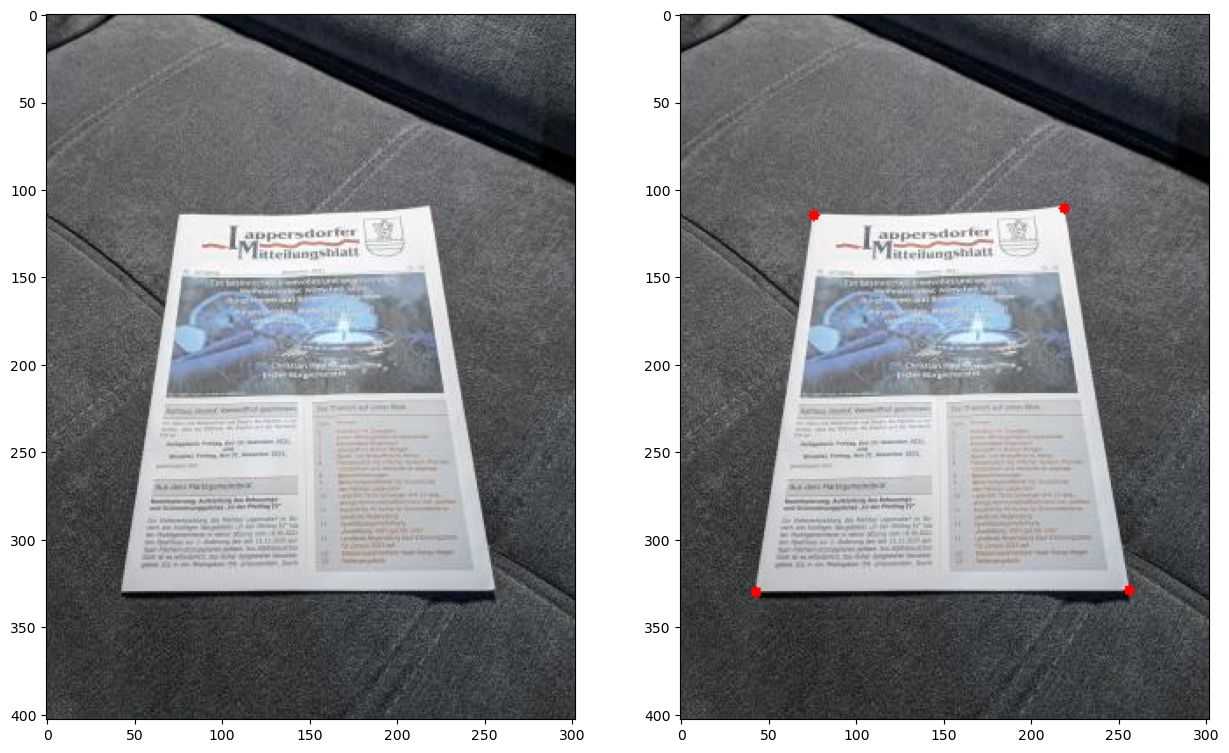

In [37]:
top_left = [76, 115]
top_right = [219, 111]
bottom_left = [43, 330]
bottom_right = [256, 329]

out = np.copy(img)
out = cv2.circle(out, tuple(top_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(top_right), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_right), 3, (255,0,0), -1)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

In [38]:

corners = [top_left, top_right, bottom_right, bottom_left]
src = np.array(corners, dtype=np.float32)
print('src : ', src)

r, c, _ = out.shape
print('shape : ', out.shape)

dst = np.array([
    [0, 0],
    [c, 0],
    [c, r],
    [0, r]
], dtype=np.float32)
print('dst : ', dst)


src :  [[ 76. 115.]
 [219. 111.]
 [256. 329.]
 [ 43. 330.]]
shape :  (403, 302, 3)
dst :  [[  0.   0.]
 [302.   0.]
 [302. 403.]
 [  0. 403.]]


transform matrix  [[ 2.10190920e+00 -3.56746057e-01 -1.18719303e+02]
 [ 5.14654237e-02  1.83988890e+00 -2.15498595e+02]]


(<Axes: >, <matplotlib.image.AxesImage at 0x30803a710>)

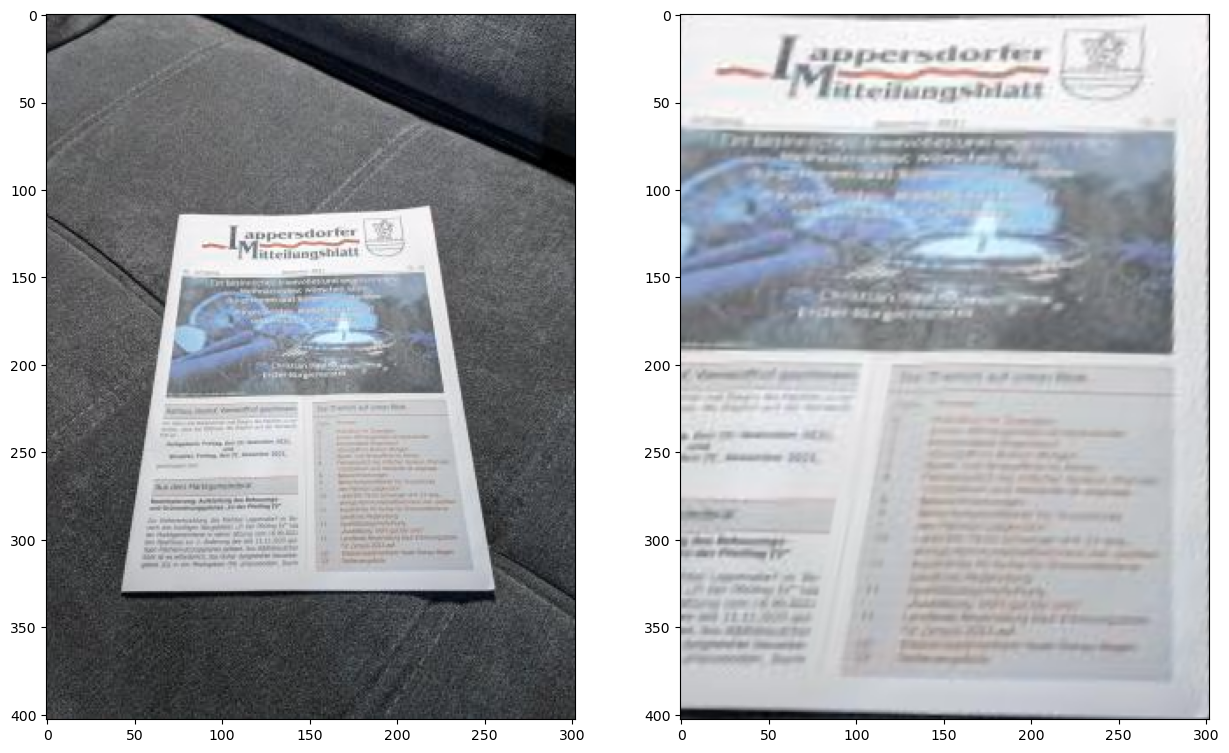

In [39]:
# Compute the affine transform matrix (you'll have to use getAffineTransform function from OpenCV here)
# Use the first 3 points from your src and dst matrix
src_affine = src[:3]
dst_affine = dst[:3]
M = cv2.getAffineTransform(src_affine, dst_affine)

print('transform matrix ', M)

# Build the rectified image using the computed matrix (you'll have to use warpAffine function from OpenCV here)
rectified = cv2.warpAffine(img, M, (c, r))

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

transform matrix  [[ 1.41671150e+00 -2.40451034e-01  1.84302468e+01]
 [ 8.67207506e-03  1.84715199e+00 -2.06933055e+02]]


(<Axes: >, <matplotlib.image.AxesImage at 0x30813da90>)

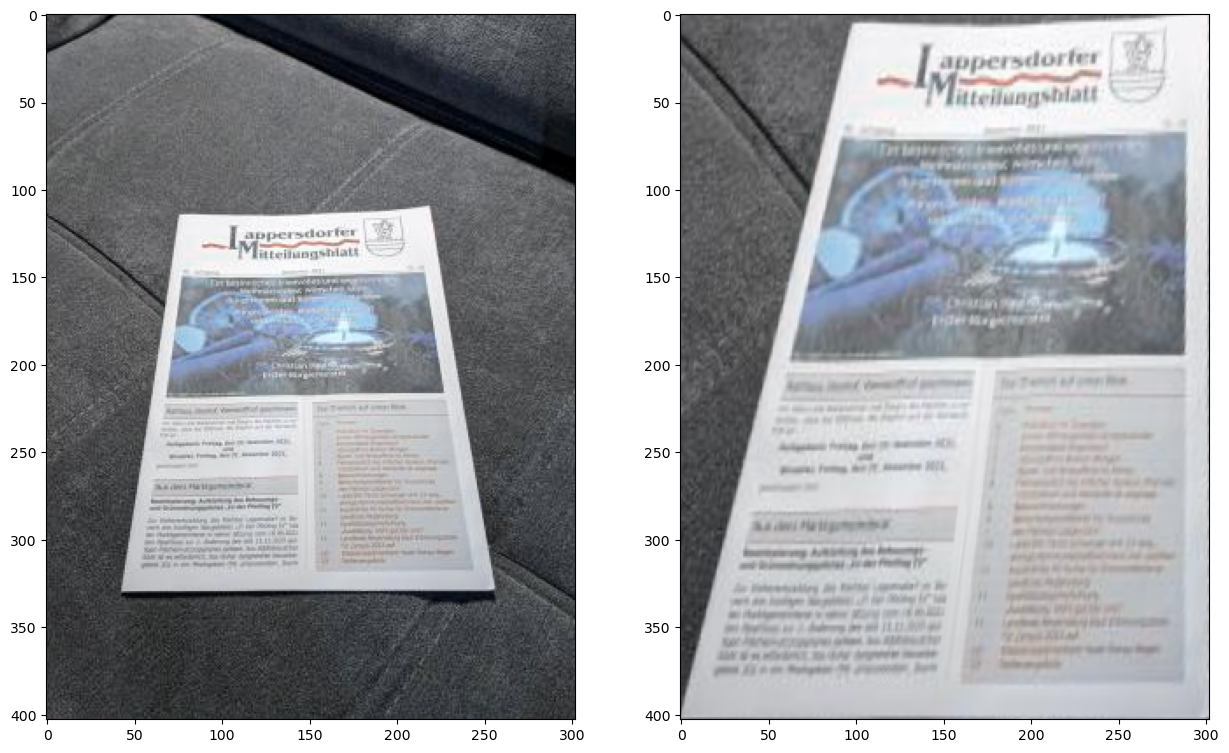

In [40]:
# Compute the affine transform matrix (use getAffineTransform)
# Use the last 3 points from your src and dst matrix
src_affine = src[1:]
dst_affine = dst[1:]
M = cv2.getAffineTransform(src_affine, dst_affine)

print('transform matrix ', M)

# Build the rectified image using the computed matrix (use warpAffine)
rectified = cv2.warpAffine(img, M, (c, r))

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

RANSAC transform matrix  [[ 2.12099435e+00  3.25547970e-01 -1.98633587e+02]
 [ 5.26573678e-02  1.88250090e+00 -2.20489563e+02]]
inliers  [[1]
 [1]
 [0]
 [1]]


(<Axes: >, <matplotlib.image.AxesImage at 0x308238f50>)

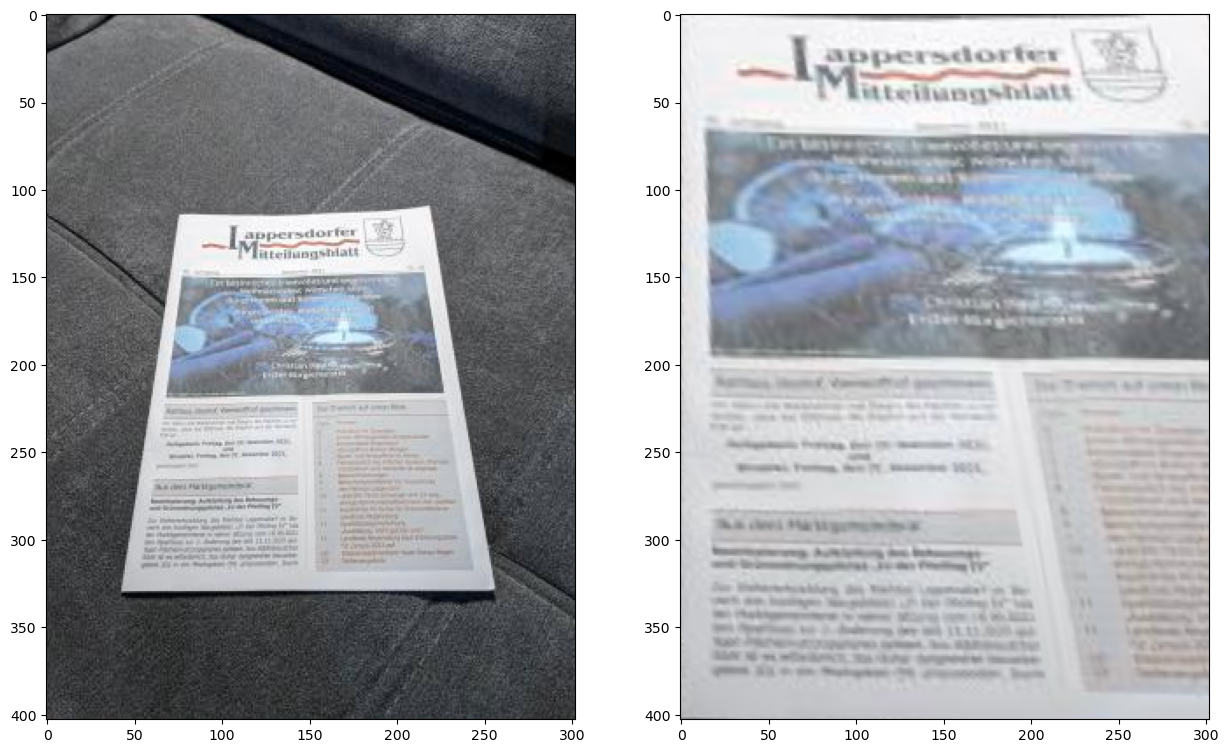

In [41]:
M, inliers = cv2.estimateAffine2D(src, dst, method=cv2.RANSAC)

print('RANSAC transform matrix ', M)
print('inliers ', inliers)

rectified = cv2.warpAffine(img, M, (c, r))

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

homography matrix  [[ 2.97004487e+00  4.55867352e-01 -2.78148156e+02]
 [ 1.07730371e-01  3.85136077e+00 -4.51093997e+02]
 [ 2.37188082e-04  3.13841065e-03  1.00000000e+00]]
homography matrix status  [[1]
 [1]
 [1]
 [1]]
transform matrix  [[ 2.97004487e+00  4.55867352e-01 -2.78148156e+02]
 [ 1.07730371e-01  3.85136077e+00 -4.51093997e+02]
 [ 2.37188082e-04  3.13841065e-03  1.00000000e+00]]


(<Axes: >, <matplotlib.image.AxesImage at 0x3083c4190>)

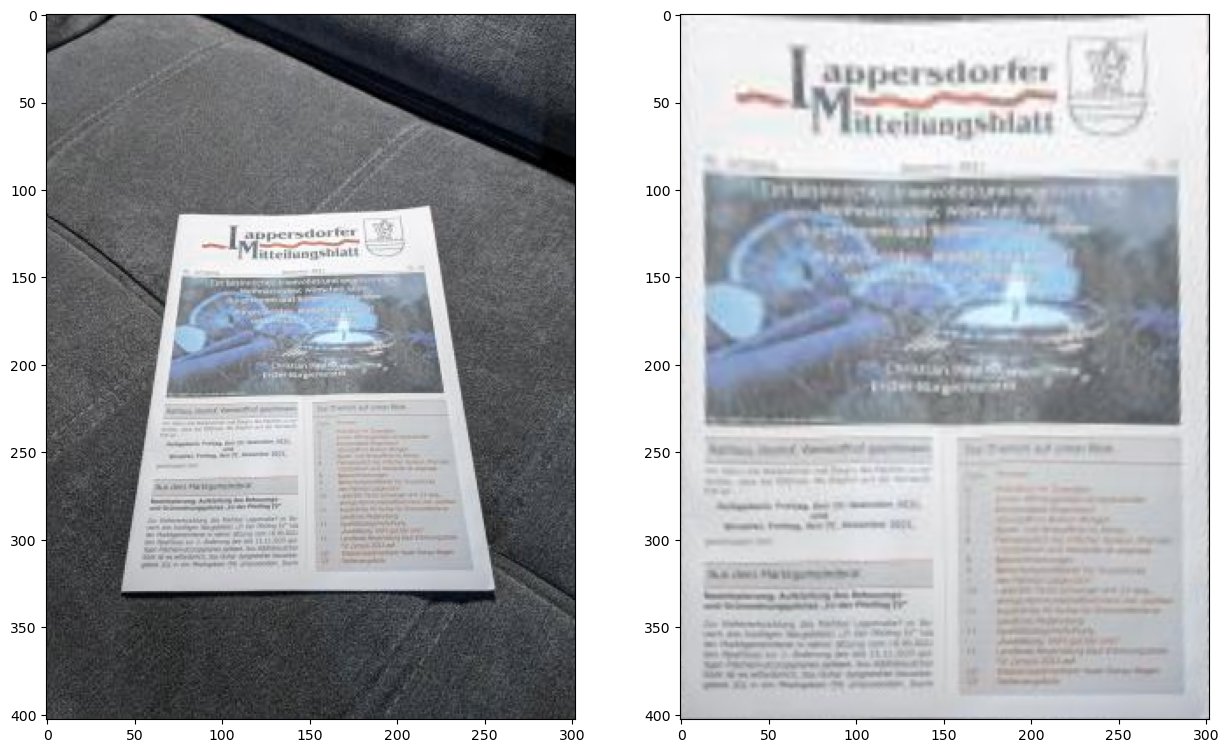

In [43]:
(H, status) = cv2.findHomography(src, dst, cv2.RANSAC, 4)
print('homography matrix ', H)
print('homography matrix status ', status)


# Compute the homography matrix (you'll have to use getPerspectiveTransform function from OpenCV here)
M = cv2.getPerspectiveTransform(src, dst)

print('transform matrix ', M)

# Build the rectified image using the computed matrix (you'll have to use warpPerspective function from OpenCV)
projection = cv2.warpPerspective(img, M, (c, r))

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(projection)

(<Axes: >, <matplotlib.image.AxesImage at 0x308902fd0>)

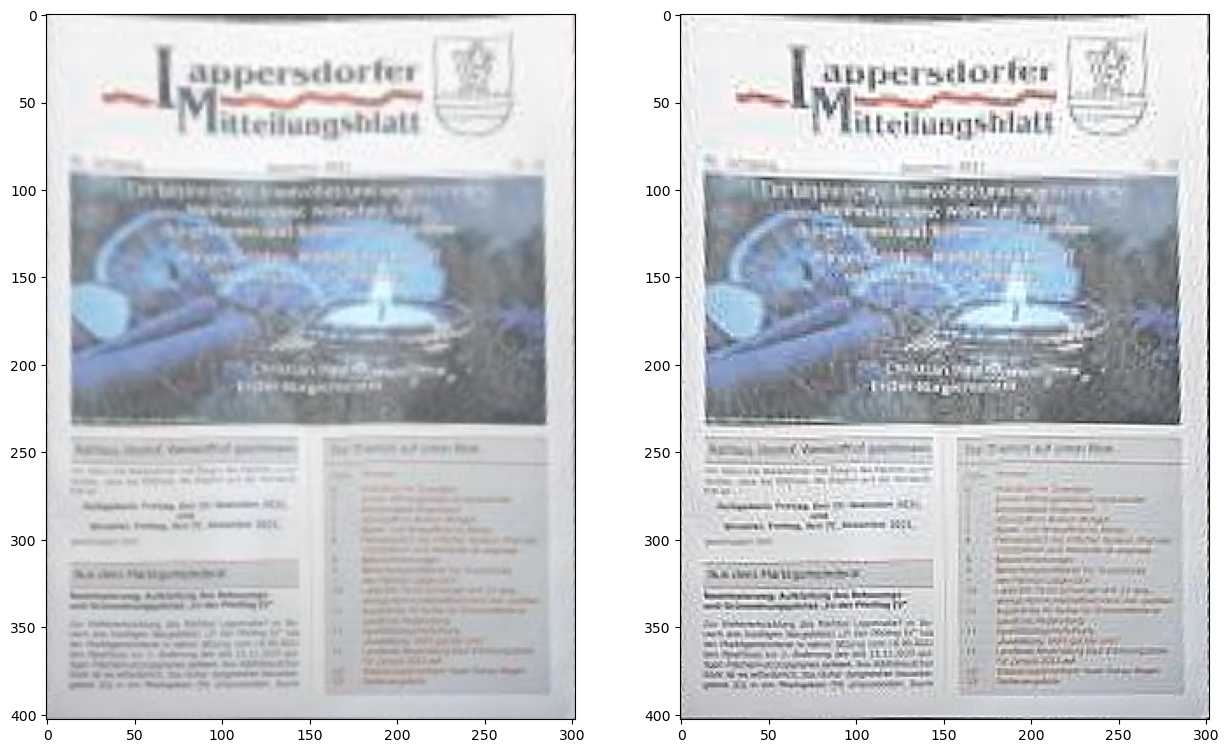

In [59]:
# The affine transform does not seem to be working well in this case. Why?
#  - Because this homography(projection). Here we need transform non-parallel lines into parallel. Affin transformation would work rotation, scaling
# What can you tell me about the values you have obtained for the inliers vector? What does it mean?
#  - That we have 2 inliers and 1 outlier:) Also we reject outliers because they do not match to affine transform
# How does the result from homography look? Does it work well enough?
#  -  I would process with sharpening filter for projection result image. But it wont provide any results because we lost data during projection

kernel = np.array([[0, -1,  0],
                   [-1, 5, -1],
                   [0, -1,  0]], dtype=np.float32)

sharpened = cv2.filter2D(projection, ddepth=-1, kernel=kernel)

plt.subplot(121), plt.imshow(projection)
plt.subplot(122), plt.imshow(sharpened)
